In [1]:
import numpy as np
import scipy as sp
from scipy.optimize import minimize, root

import CoolProp.CoolProp as CP

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Initialization


# Plotting
sns.set_theme()
plt.rcParams['text.usetex'] = True

In [3]:
# aliases
norm = sp.linalg.norm
pi = np.pi

# constants (SI)
g0 = sp.constants.g     # At sea level
p0 = sp.constants.atm   # At sea level
T_room = 290            # ~ Israeli winter temperature in Kelvin

seasurface_density = CP.PropsSI('D', 'T', T_room, 'P', p0, 'Water')
viscosity = CP.PropsSI('VISCOSITY', 'T', T_room, 'P', p0, 'Water')  # Pa.s
kinematic_viscosity = viscosity / seasurface_density
seawater_surface_tension = 0.074  # N/m, estimate for seawater, +-0.001

# aliases
rho = seasurface_density
mu = viscosity
nu = kinematic_viscosity
tau_bare = seawater_surface_tension

In [4]:
N = int(2e3)
k_max = 2*np.pi*int(2e2)    # rad/m
k_ps = np.linspace(k_max/N, k_max, num=N).reshape((N,1))
k_ps_abs = norm(k_ps, axis=-1)

In [5]:
def det_matrix(
    omega, k,
    rho, nu, kappa, T0,
    k_e, k_v, D
    ):
    
    i = 1j
    m = np.sqrt(k**2 - i*omega/nu)
    n = np.sqrt(k**2 - i*omega/D)
    if np.real(m) < 0:
        m = -m
    if np.real(n) < 0:
        n = -n

    a11 = (
        (k_v/(rho*nu) * k + 2) * omega
        + 1j * (k_e/(rho*nu) * k + 2*D/kappa * n)
    )

    a12 = (
        -(D/kappa * (m**2/k**2 + 1) * n + k_e/(rho*nu) * m)
        + 1j * ((m**2/k**2 + 1) + k_v/(rho*nu) * m) * omega
    )

    a21 = (
        2*rho*nu*omega / (T0*k)
        + 1j * (rho*(2*g0*k - omega**2) / (T0*k**3) + 1)
    )

    a22 = (
        -(2*rho*g0 / (T0*k**2) + 1)
        + 1j * 2*rho*nu / T0 * m*omega / k**2
    )

    M = np.array([[a11, a12],
                  [a21, a22]], dtype=np.complex128)

    return np.linalg.det(M)

In [6]:
# units in SI, values for sea water

def dispersion_func(omega, k):
    return det_matrix(
        omega,
        k,
        rho=rho,
        nu=nu,
        kappa=1e-5,
        T0=0.04,
        k_e=0.04,
        k_v=1e-9,
        D=1e-9
        )

# --- Solver for one k ---
bounds = [
    (1e-12, None),  # Re(ω) > 0
    (None, -1e-12)
    ] # Im(ω) < 0

def solve_for_k(k):
    # initial guess: inviscid dispersion relation
    k_abs = norm(k, axis=-1)
    print(k_abs)

    omega0 = 1.2 * np.sqrt(g0*k_abs + (tau_bare/rho) * k_abs**3) - 1j*(20*nu*k_abs**2)
    # solve numerically

    try:
        # sol = minimize(
        #     fun=lambda w: np.abs(dispersion_func(w[0] + 1j*w[1], k_abs))**2,
        #     x0=[np.real(omega0), np.imag(omega0)],
        #     method='L-BFGS-B',
        #     bounds=bounds
        # )
        sol = root(
            lambda w: [
                dispersion_func(w[0] + 1j*w[1], k_abs).real,
                dispersion_func(w[0] + 1j*w[1], k_abs).imag
            ],
            x0=[np.real(omega0), np.imag(omega0)],
            method='hybr'  # or 'lm', 'broyden1', 'krylov', etc.
        )
        return sol.x[0] + 1j*sol.x[1]
    except Exception:
        return np.nan + 1j*np.nan


In [7]:
omegas = np.array([solve_for_k(k) for k in k_ps])

0.6283185307179586
1.2566370614359172
1.8849555921538759
2.5132741228718345
3.141592653589793
3.7699111843077517
4.39822971502571
5.026548245743669
5.654866776461628
6.283185307179586
6.911503837897545
7.5398223686155035
8.168140899333462
8.79645943005142
9.42477796076938
10.053096491487338
10.681415022205297
11.309733552923255
11.938052083641214
12.566370614359172
13.194689145077131
13.82300767579509
14.451326206513048
15.079644737231007
15.707963267948966
16.336281798666924
16.964600329384883
17.59291886010284
18.2212373908208
18.84955592153876
19.477874452256717
20.106192982974676
20.734511513692635
21.362830044410593
21.991148575128552
22.61946710584651
23.24778563656447
23.876104167282428
24.504422698000386
25.132741228718345
25.761059759436304
26.389378290154262
27.01769682087222
27.64601535159018
28.274333882308138
28.902652413026097
29.530970943744055
30.159289474462014
30.787608005179973
31.41592653589793
32.044245066615886
32.67256359733385
33.30088212805181
33.92920065876977

In [8]:
omegas_bare = np.sqrt(g0*k_ps_abs + (tau_bare/rho) * k_ps_abs**3)

Text(0, 0.5, '$\\frac{k}{2\\pi} [mm^{-1}]$')

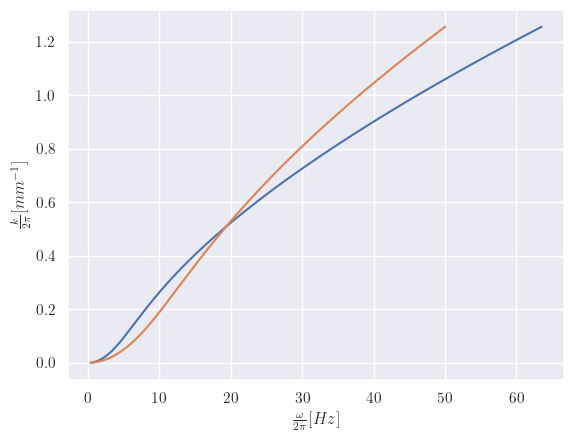

In [9]:
plt.figure()
plt.plot(omegas_bare/(2*pi), k_ps_abs/1000)
plt.plot(np.real(omegas)/(2*pi), k_ps_abs/1000)
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
plt.ylabel(r"$\frac{k}{2\pi} [mm^{-1}]$")
# plt.figure()
# plt.plot(np.imag(omegas), k_ps_abs)

Text(0, 0.5, '$\\alpha [s^{-1}]$')

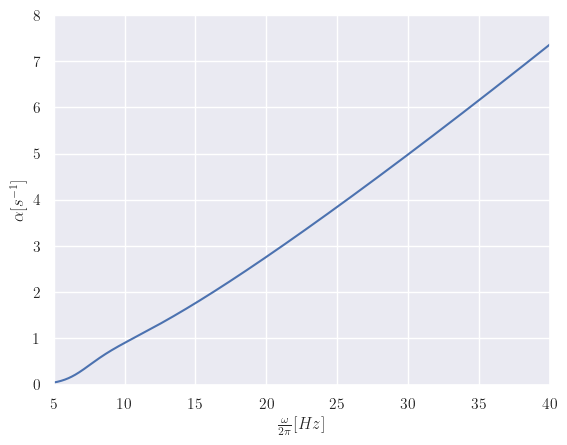

In [10]:
plt.plot(
    np.real(omegas)/(2*pi), 
    -np.imag(omegas)
    )
plt.xlim(5,40)
plt.ylim(0, 8)
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
plt.ylabel(r"$\alpha [s^{-1}]$")


(5.0, 40.0)

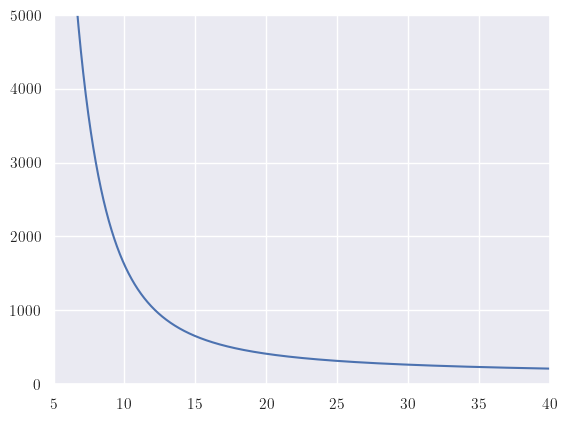

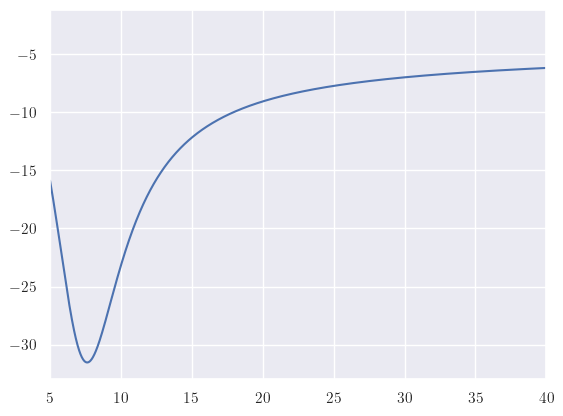

In [21]:
W = omegas / (nu * k_ps_abs**2)
            # Linear waves at a surfactant-contaminated interface separating two
            # fluids: Dispersion and dissipation of capillary-gravity waves, 
            # Girish K. Rajan and Diane M. Henderson, 2018

plt.figure()
plt.plot(
    np.real(omegas)/(2*pi),
    np.real(W)
)
plt.xlim(5, 40)
plt.ylim(0,5000)

plt.figure()
plt.plot(
    np.real(omegas)/(2*pi),
    np.imag(W)
)
plt.xlim(5, 40)



## Dispersion for certain surfactants

### Types of naturally occurring marine surfactants

1. Proteinaceous Material and Amino Acids: Breakdown products from plankton often dominate the surface-active material.
2. Lipids and Fatty Acids: These are major components of the organic film, often found in conjunction with degradation products.
3. Transparent Exopolymer Particles (TEP): Carbohydrate-rich particles generated by microorganisms.
4. Glycopeptides-Lipid-Oligosaccharide Complexes: Complex organic molecules that accumulate at the marine interface.
5. Humic Substances: Often present in coastal waters, contributing to the overall surfactant activity. 
